# `dtd-horowitz` — Horowitz's (1984) cost-smoothing SUE dynamics

**What.** Travellers carry an exponentially-smoothed perceived link-cost vector p, logit-load at p, and update p ← (1−w) p + w t(v) toward experienced costs. The rest point is the logit SUE.

**Why it is in the benchmark.** Its distinctive property is a STABILITY THRESHOLD: the constant-weight smoothing map is a stable attractor only below w* ≈ 0.81 on this anchor; above it (w=1, the naive current-cost model) it settles into a period-2 limit cycle — the instability the model exists to exhibit, so no damping is applied. See the
[model compendium](../../docs/MODELS.md) and the certificate design in
[docs/ARCHITECTURE.md](../../docs/ARCHITECTURE.md) (P1).

**Scope.** Runs the process on a built-in scenario and certifies the result; it does
not benchmark day-to-day models against each other. Reference: Horowitz, J.L. (1984), *Transportation Research Part B* 18(1).

**Canon.** `[horowitz1984stability]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every scored
quantity below is recomputed live by the P1 `Evaluator` from the flows the model
emitted, in the cell where it is claimed. Model self-reports (the per-day gap/residual,
the Lyapunov value) are shown only as provenance and diffed against the certificate,
exactly as the harness treats them ([README](../../README.md), *Certified, not
self-reported*).

In [1]:
# Setup. `dtd-horowitz` is a core day-to-day model: a plain `pip install -e .` suffices —
# no optional extra, so no guard cell. The inline backend is Agg-based (headless CI
# renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it silently
# suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    Budget,
    CostSmoothingSUEModel,
    Evaluator,
    RngBundle,
    Trace,
    two_route_scenario,
    viz,
)

## The scenario

The built-in two-route logit-SUE anchor (demand 4, dispersion θ=0.5): route A cost 2+f_A,
route B cost 1.5+2 f_B. Its rest point is the binary-logit stochastic user equilibrium,
recomputed analytically in the certify cell — NOT the deterministic Wardrop UE.

In [2]:
scenario = two_route_scenario()
net = scenario.network
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"links         : {net.n_links}  (tail→head: "
      + ", ".join(f"{i}->{j}" for i, j in zip(net.init_node, net.term_node)) + ")")
print(f"total demand  : {scenario.demand.total}")
print("task          : logit SUE, θ=0.5")

scenario      : tworoute
content hash  : 9b98e58b339b702f…
links         : 4  (tail→head: 1->3, 3->2, 1->4, 4->2)
total demand  : 4.0
task          : logit SUE, θ=0.5


## Run the adjustment process

The model contract ([CONTRIBUTING.md](../../CONTRIBUTING.md)): a model receives
`(scenario, budget, rng, trace)` and records one checkpoint per day — here a *budget
iteration is a day*. Everything the model writes into `self_report` (the per-day
gap/residual, the Lyapunov value) is provenance, not a score.

In [3]:
bundle_trace = Trace()
model = CostSmoothingSUEModel(smoothing_weight=0.3)
# Run the full horizon (no early-stop): the SUE residual settles in ~15 days but the
# perceived-cost state keeps relaxing, and its vanishing is part of what we certify.
model.solve(scenario, Budget(iterations=500), RngBundle(0), bundle_trace)
final = bundle_trace.final
print(f"model            : {model.name}")
print(f"days simulated   : {final.coords.iterations}  "
      f"({final.coords.sp_calls} shortest-path calls)")
print(f"emitted flows    : {np.round(final.link_flows, 6)}")
print(f"self-reported residual: {final.self_report['sue_fixed_point_residual']:.3e}  (provenance only)")

model            : dtd-horowitz
days simulated   : 500  (1000 shortest-path calls)
emitted flows    : [2.299096 2.299096 1.700904 1.700904]
self-reported residual: 3.331e-16  (provenance only)


## Certify (P1) — the SUE fixed point AND the descent

The harness recomputes the ADR-001 Dial-STOCH residual from the emitted flows. Certified
here: (1) the terminal flows are the logit SUE — residual → 0 with the analytic binary-
logit anchor recomputed in-cell, while the *deterministic* UE gap stays positive (a
descriptive column, like `sue-msa`); (2) the model's Lyapunov / provenance signature.

In [4]:
from scipy.optimize import brentq
evaluator = Evaluator(scenario)
metrics = evaluator.evaluate(final.link_flows)
residual = metrics["sue_fixed_point_residual"]
print(f"certified SUE residual : {residual:.3e}")
print(f"feasible               : {metrics['feasible']:.0f}")
print(f"UE relative gap        : {metrics['relative_gap']:.3f}  (stays >0 — logit SUE ≠ deterministic UE)")
assert metrics["feasible"] == 1.0
assert residual < 1e-5
assert metrics["relative_gap"] > 0.01  # descriptive column: not the deterministic UE

# Analytic binary-logit SUE anchor, recomputed in-cell (θ=0.5, demand 4): the root of
# f_A = D / (1 + exp(θ(c_A − c_B))), c_A = 2 + f_A, c_B = 1.5 + 2(4 − f_A).
def _resid(f_a):
    c_a, c_b = 2.0 + f_a, 1.5 + 2.0 * (4.0 - f_a)
    return f_a - 4.0 / (1.0 + np.exp(0.5 * (c_a - c_b)))
f_a = brentq(_resid, 0.0, 4.0, xtol=1e-12)
ref_flows = np.array([f_a, f_a, 4.0 - f_a, 4.0 - f_a])
print(f"analytic logit SUE f_A : {f_a:.6f}")
assert np.allclose(final.link_flows, ref_flows, atol=1e-3)
# Honesty (P1): the model self-reports the SAME residual the harness recomputes.
assert np.isclose(
    final.self_report["sue_fixed_point_residual"], residual, rtol=1e-9, atol=1e-12
)
# The perceived-cost gap ||p − t(v)||₁ vanishes at rest. PROVENANCE ONLY -- the
# certified Evaluator has no perceived-cost counterpart (p is internal model state,
# not a certifiable artifact); the SUE fixed point itself is what is certified above.
pgap = [s.self_report["perceived_cost_gap"] for s in bundle_trace]
assert max(pgap) > 1.0 and pgap[-1] < 1e-6
print(f"perceived-cost gap (provenance only) : {max(pgap):.3g} → {pgap[-1]:.2e}")

# The stability threshold w* ≈ 0.81 named in the header, recomputed (not quoted):
# forward-Euler stability of the scalar day map at the fixed point f* requires
# w < 2/(1-Phi'(f*)), where Phi is the logit response map f_A -> D/(1+exp(theta*
# (c_A(f_A)-c_B(f_A)))) and Phi' its derivative at f* (chain rule through
# c_A-c_B = 3 f_A - 7.5, dz/df_A = theta*3).
z_star = 0.5 * (3.0 * f_a - 7.5)
phi_prime = -4.0 * 3.0 * 0.5 * np.exp(z_star) / (1.0 + np.exp(z_star)) ** 2
w_star = 2.0 / (1.0 - phi_prime)
print(f"stability threshold w*  : {w_star:.4f}  (Phi'(f*)={phi_prime:.4f})")
assert 0.80 < w_star < 0.82  # brackets the w=0.5 stable / w=1.0 unstable runs below

# DISTINCTIVE: the constant-weight smoothing map is stable only below w* ≈ 0.81 on this
# anchor. At w = 1.0 (Horowitz's naive current-cost model) it settles into a period-2
# LIMIT CYCLE — the certified residual stays O(1). No damping is added; the instability
# is what the model exists to exhibit.
unstable = Trace()
CostSmoothingSUEModel(smoothing_weight=1.0).solve(
    scenario, Budget(iterations=400), RngBundle(0), unstable
)
res_u = [s.self_report["sue_fixed_point_residual"] for s in unstable]
fa_tail = np.array([s.link_flows[0] for s in unstable])[-50:]
print(f"w=1.0 terminal residual: {res_u[-1]:.3f}  (period-2 limit cycle, not a fixed point)")
assert res_u[-1] > 1.0
assert fa_tail.max() - fa_tail.min() > 1.0  # a genuine oscillation band

certified SUE residual : 3.331e-16
feasible               : 1
UE relative gap        : 0.056  (stays >0 — logit SUE ≠ deterministic UE)
analytic logit SUE f_A : 2.299096
perceived-cost gap (provenance only) : 6.25 → 1.78e-15
stability threshold w*  : 0.8109  (Phi'(f*)=-1.4665)
w=1.0 terminal residual: 3.323  (period-2 limit cycle, not a fixed point)


## Visualize

Both figures come from `tabench.viz`, the house visualizer — every plotted number is one
certified above. Left/top: the certified terminal link flows on the network. Right/bottom:
the emitted flows against the fixed point recomputed in the certify cell — points on the
`y = x` guide mean the day-to-day process settled on it link-for-link.

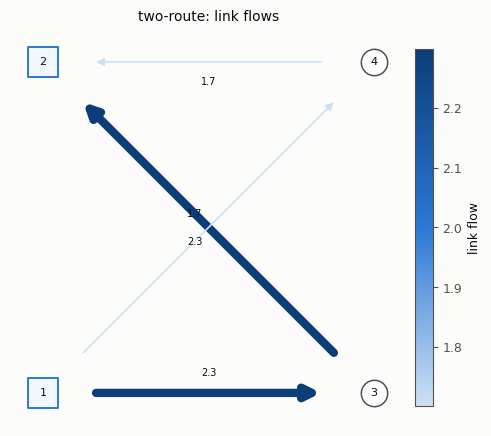

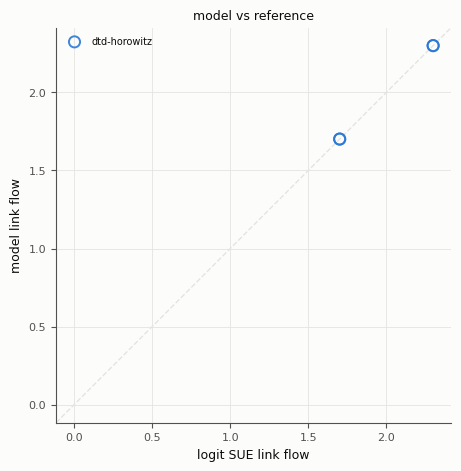

In [5]:
# Certified terminal flows on the network (house style via tabench.viz).
display(viz.plot_network_flows(net, final.link_flows))

# Emitted flows vs the logit SUE recomputed above (off-diagonal == not settled).
display(viz.plot_flow_scatter(("logit SUE", ref_flows), {"dtd-horowitz": final.link_flows}))

## Takeaways & pointers

- **Certified, not self-reported.** The residual came from `Evaluator` at w=0.3 (stable) and, in contrast, at w=1.0 (a certified O(1) limit cycle) — both scored by the identical certificate.
- **The day-to-day signature is the point.** A UE/SUE *solver* gives you the fixed
  point; a day-to-day *model* gives you the adjustment path to it.
- **Where next.** the route-swap SUE process [`dtd-swap-sue`](02-dtd-swap-sue.ipynb); the stochastic sampling process [`dtd-stochastic`](06-dtd-stochastic.ipynb); the lineage in the
  [model compendium](../../docs/MODELS.md).